# The Yinzer Index - Nightlife Metric (Darsh)

This notebook calculates a nightlife score for Pittsburgh neighborhoods by counting food facilities/restaurants.

Idea: more restaurants and food spots means more nightlife options for young adults.

In [2]:
# Step 1: Import libraries and set plotting style
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

## Step 2: Load and inspect the food facilities dataset

In [4]:
# Read the CSV file
food = pd.read_csv('data/food_facilities.csv')

# Quick look at the columns and first few rows
print('Rows:', len(food))
print(food.columns.tolist())
food.head()

Rows: 6389
['_id', 'inspection_id', 'placard_desc', 'facility_name', 'bus_st_date', 'facility_type', 'category', 'nonprofit', 'num', 'street', 'city', 'state', 'zip_code', 'municipal', 'inspect_dt', 'inspection_purpose', 'reinspection_need', 'permit_status']


,_id,inspection_id,placard_desc,facility_name,bus_st_date,facility_type,category,nonprofit,num,street,city,state,zip_code,municipal,inspect_dt,inspection_purpose,reinspection_need,permit_status
0,134674,1027102,Inspected & Permitted,Slavonic Social Club,1984-06-17,Food Facility,250-Social Club-Bar Only,Yes,1025,WOODLAWN AV,BRADDOCK,PA,15104.0,BRADDOCK,2025-09-05,Comprehensive,No,Active
1,134675,1016535,Inspected & Permitted,VFW / Post #118,1984-06-17,Food Facility,250-Social Club-Bar Only,No,605,NORTH AV,PITTSBURGH,PA,15209.0,MILLVALE,2025-08-25,Comprehensive,No,Active
2,134676,1018096,Inspected & Permitted,Allegheny HYP Club,1931-01-01,Food Facility,201-Restaurant with Liquor,No,619,WILLIAM PENN PL,PITTSBURGH,PA,15219.0,PITTSBURGH-102,2025-08-26,Comprehensive,No,About to Expire
3,134677,1015989,Inspected & Permitted,DeCarlos Market,1980-01-01,Food Facility,113-Retail/Convenience Store,No,560,MCKEESPORT RD,ELIZABETH,PA,15037.0,ELIZABETH TOWNSHIP,2025-09-09,Reinspection,No,About to Expire
4,134678,1015986,Inspected & Permitted,DeCarlos Market,1980-01-01,Food Facility,113-Retail/Convenience Store,No,560,MCKEESPORT RD,ELIZABETH,PA,15037.0,ELIZABETH TOWNSHIP,2025-08-25,Comprehensive,Yes,About to Expire


## Step 3: Clean zip codes and remove duplicate facilities

In [ ]:
# Keep zip code as a 5-digit string
food['zip_code'] = food['zip_code'].astype(str).str.strip().str[:5]

# Remove duplicates caused by multiple inspections of the same facility
food_unique = food.drop_duplicates(subset=['facility_name', 'zip_code']).copy()

print('Rows after removing duplicate facilities:', len(food_unique))

Rows after removing duplicate facilities: 4939


## Step 4: Map Pittsburgh zip codes to neighborhoods

In [7]:
# Zip-to-neighborhood mapping for Pittsburgh areas
zip_to_neighborhood = {
    '15201': 'Lawrenceville',
    '15203': 'South Side',
    '15206': 'East Liberty',
    '15210': 'Carrick',
    '15211': 'Mt Washington',
    '15212': 'North Side',
    '15213': 'Oakland',
    '15217': 'Squirrel Hill',
    '15219': 'Downtown',
    '15222': 'Strip District',
    '15224': 'Bloomfield',
    '15226': 'Brookline',
    '15232': 'Shadyside',
    '15202': 'North Side',
    '15204': 'West End',
    '15205': 'Westwood',
    '15207': 'Hazelwood',
    '15208': 'Point Breeze',
    '15214': 'Brighton Heights',
    '15216': 'Beechview',
    '15218': 'Squirrel Hill',
    '15220': 'Crafton Heights',
    '15221': 'East End',
    '15227': 'Brookline'
}

# Create neighborhood column using the zip mapping
food_unique.loc[:, 'neighborhood'] = food_unique['zip_code'].map(zip_to_neighborhood)

# Keep only rows where we mapped a neighborhood
food_pgh = food_unique.dropna(subset=['neighborhood']).copy()

print('Rows with mapped neighborhoods:', len(food_pgh))

Rows with mapped neighborhoods: 2038


## Step 5: Count facilities and calculate nightlife score

In [8]:
# Count unique facilities in each neighborhood
nightlife_counts = food_pgh.groupby('neighborhood')['facility_name'].nunique().reset_index()
nightlife_counts = nightlife_counts.rename(columns={'facility_name': 'facility_count'})

# Make a 0 to 1 score (higher facility count = better nightlife)
lowest = nightlife_counts['facility_count'].min()
highest = nightlife_counts['facility_count'].max()
spread = highest - lowest

if spread == 0:
    nightlife_counts['nightlife_score'] = 1.0
else:
    nightlife_counts['nightlife_score'] = (nightlife_counts['facility_count'] - lowest) / spread

nightlife_scores = nightlife_counts[['neighborhood', 'nightlife_score']].sort_values('nightlife_score', ascending=False)
nightlife_scores.head(10)

,neighborhood,nightlife_score
18,Strip District,1.000000
13,Oakland,0.915094
12,North Side,0.910377
20,Westwood,0.693396
17,Squirrel Hill,0.688679
8,East Liberty,0.632075
6,Downtown,0.570755
3,Brookline,0.533019
16,South Side,0.405660
10,Lawrenceville,0.382075


## Step 6: Visualize nightlife scores

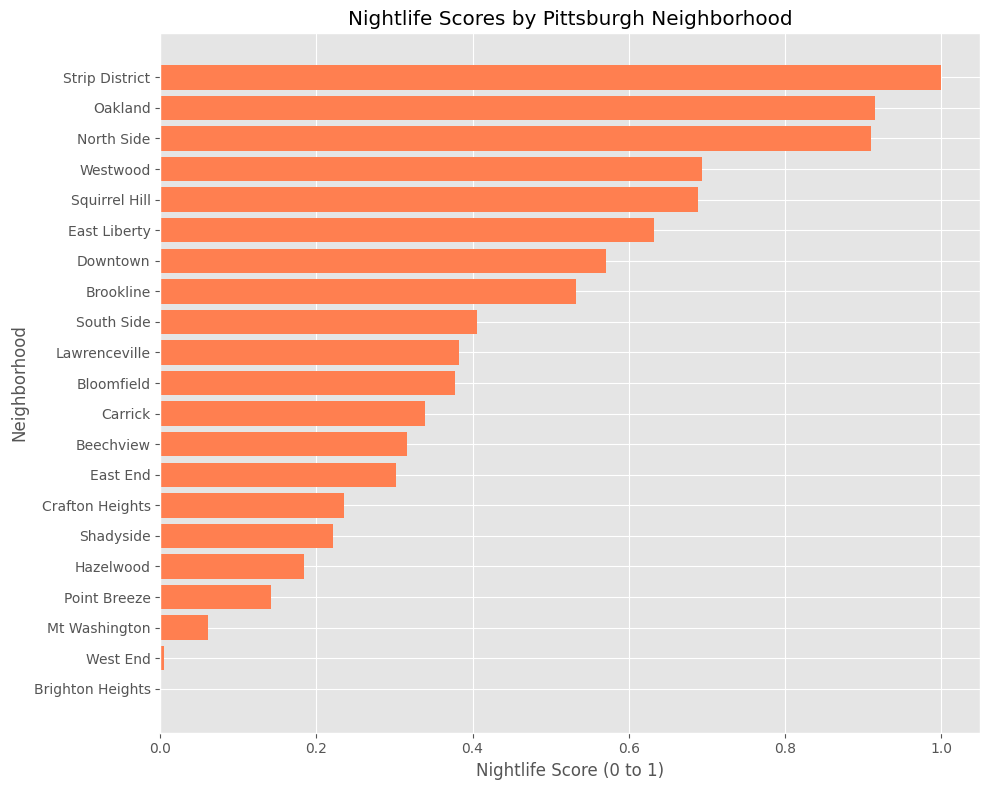

In [ ]:
# Plot top 15 nightlife neighborhoods so the chart is easier to read
top_nightlife = nightlife_scores.head(15).sort_values(by='nightlife_score', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_nightlife['neighborhood'], top_nightlife['nightlife_score'], color='coral')
plt.xlabel('Nightlife Score (0 to 1)')
plt.ylabel('Neighborhood')
plt.title('Top 15 Nightlife Neighborhoods')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Step 7: Save scores for final report

In [10]:
# Save only neighborhood and normalized nightlife score
import os
os.makedirs('scores', exist_ok=True)
nightlife_scores.to_csv('scores/nightlife_scores.csv', index=False)
print('Saved scores/nightlife_scores.csv')

Saved scores/nightlife_scores.csv


## Conclusion

[DARSH - Write 3-4 sentences about what neighborhoods scored high in nightlife and why this matters for young adults.]